In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def add_src_to_path():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        src = p / "src"
        if src.is_dir():
            sys.path.insert(0, str(src))
            print(f"✅ Added to sys.path: {src}")
            return src
    raise FileNotFoundError(
        f"Could not find a 'src' directory by walking up from {here}.\n"
        f"Current working dir is: {here}"
    )

SRC_DIR = add_src_to_path()
print("First sys.path entry:", sys.path[0])


✅ Added to sys.path: /home/user/src
First sys.path entry: /home/user/src


In [3]:
import torch
from collections import OrderedDict
from models.LIANet import LIANetLight
from utils import _preprocess_S2, s2_to_rgb
from datetime import datetime
topdir = "/home/user/data/extended_area_experiment_data" 
tile_names = ["T16TEK", "T16TFK"] 
image_size = 128 


model = LIANetLight(
    timestamp_dim=43, 
    time_mode="fourier_learned", 
    num_time_frequencies=8, 
    time_input_dim=3, 
    time_mlp_hidden=64, 
    levels=13, 
    n_min=16, 
    growth=2, 
    table_size=524288, # 2^19 
    feat_dim=128, 
    complete_tile_size=20976, # Sentinel-2 max tile size 
    resunet_backbone_size="small", 
    bilinear=True, 
    out_channels=12, 
    preproj_channels=128 
    )
ckpt_path = "/home/user/pretraining_results/fourier_learned_2tile_alltimes/2026-01-11_12-03-58/model_checkpoints/checkpoint_Epoch200_Iteration457000.pt"
def normalize_state_dict_keys(state_dict):
    """
    Make checkpoint keys compatible across common wrappers:
    - DDP:        'module.'
    - torch.compile / wrappers: '_orig_mod.'
    """
    new_state = OrderedDict()
    for k, v in state_dict.items():
        # peel off multiple possible prefixes (order matters)
        for prefix in ("module.", "_orig_mod."):
            if k.startswith(prefix):
                k = k[len(prefix):]
        new_state[k] = v
    return new_state

ckpt = torch.load(ckpt_path, map_location="cpu")

if isinstance(ckpt, dict):
    if "model_state_dict" in ckpt:
        state = ckpt["model_state_dict"]
    elif "state_dict" in ckpt:
        state = ckpt["state_dict"]
    elif "model" in ckpt:
        state = ckpt["model"]
    else:
        state = ckpt
else:
    raise ValueError("Checkpoint is not a dict.")

new_state = normalize_state_dict_keys(state)

missing, unexpected = model.load_state_dict(new_state, strict=False)
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))
if len(missing) < 50 and len(unexpected) < 50:
    print("Missing:", missing)
    print("Unexpected:", unexpected)


Missing keys: 0
Unexpected keys: 0
Missing: []
Unexpected: []


In [3]:
model.eval()

dt = datetime(2023, 6, 25, 10, 16, 1)
t0 = datetime(2015, 1, 1)
delta = (dt - t0).total_seconds() / 86400.0  # days since t0


import itertools
patch_size = 128
# x_start, x_end = 9000, 11560
x_start, x_end = 2000, 4560
y_start, y_end = 3000, 3640

x_coords = range(x_start, x_end - patch_size + 1, patch_size)
y_coords = range(y_start, y_end - patch_size + 1, patch_size)

xy_pairs = list(itertools.product(x_coords, y_coords))
xy_tensor = torch.tensor(xy_pairs, dtype=torch.long)
generated_patches = np.empty(shape=(12, 2560, 640))
for coord in xy_tensor:
    x0 = torch.tensor([coord[0]], dtype=torch.long)        # [1]
    y0 = torch.tensor([coord[1]], dtype=torch.long)        # [1]
    # print(x0, y0)
    generated_patches[:, coord[0]-x_start:coord[0]-x_start+patch_size, coord[1]-y_start:coord[1]-y_start+patch_size] = model(torch.Tensor([delta]), y0, x0).detach().numpy()
    # generated_patches = model(torch.Tensor([delta]), y0, x0).detach().numpy()

KeyboardInterrupt: 

In [4]:
tile_1_dir = "../../data/extended_area_experiment_data/T16TEK/20220107T163649.tif"
tile_2_dir = "../../data/extended_area_experiment_data/T16TFK/20220107T163649.tif"

import rasterio
with rasterio.open(tile_1_dir) as src:
    tile_1_img = src.read()
# tile_1_img.shape
with rasterio.open(tile_2_dir) as src:
    tile_2_img = src.read()

left_img = s2_to_rgb(_preprocess_S2(tile_1_img))
right_img = s2_to_rgb(_preprocess_S2(tile_2_img))

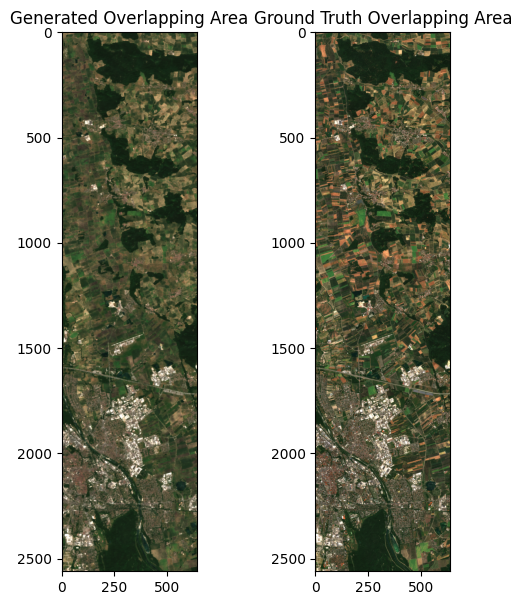

In [62]:
# print(left_img.shape, right_img.shape)
fig, ax = plt.subplots(1, 2, figsize=(6,7))
ax[0].imshow(s2_to_rgb(generated_patches))
ax[0].set_title("Generated Overlapping Area")
ax[1].imshow(left_img[2000:4560,4000:4640])
ax[1].set_title("Ground Truth Overlapping Area")
plt.show()


In [66]:
model.eval()

dt = datetime(2023, 6, 25, 10, 16, 1)
t0 = datetime(2015, 1, 1)
delta = (dt - t0).total_seconds() / 86400.0  # days since t0


import itertools
patch_size = 128
x_start, x_end = 9000, 11560
# x_start, x_end = 2000, 4560
y_start, y_end = 3000, 3640

x_coords = range(x_start, x_end - patch_size + 1, patch_size)
y_coords = range(y_start, y_end - patch_size + 1, patch_size)

xy_pairs = list(itertools.product(x_coords, y_coords))
xy_tensor = torch.tensor(xy_pairs, dtype=torch.long)
generated_patches = np.empty(shape=(12, 2560, 640))
for coord in xy_tensor:
    x0 = torch.tensor([coord[0]], dtype=torch.long)        # [1]
    y0 = torch.tensor([coord[1]], dtype=torch.long)        # [1]
    # print(x0, y0)
    generated_patches[:, coord[0]-x_start:coord[0]-x_start+patch_size, coord[1]-y_start:coord[1]-y_start+patch_size] = model(torch.Tensor([delta]), y0, x0).detach().numpy()
    # generated_patches = model(torch.Tensor([delta]), y0, x0).detach().numpy()

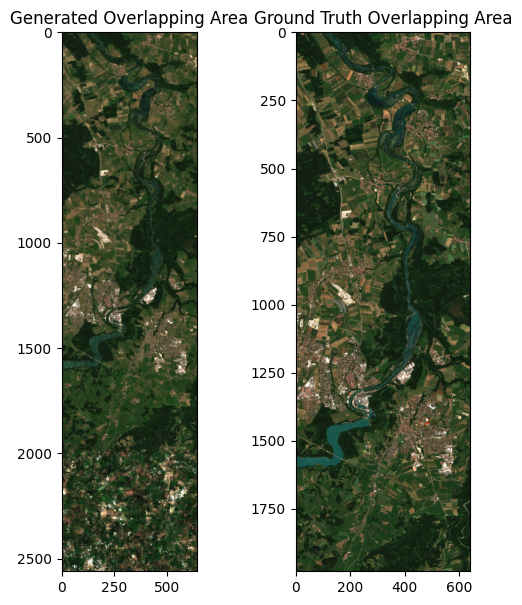

In [70]:
# print(left_img.shape, right_img.shape)
fig, ax = plt.subplots(1, 2, figsize=(6,7))
ax[0].imshow(s2_to_rgb(generated_patches))
ax[0].set_title("Generated Overlapping Area")
ax[1].imshow(left_img[9000:,4000:4640])
ax[1].set_title("Ground Truth Overlapping Area")
plt.show()


In [4]:
model.eval()

dt = datetime(2023, 6, 25, 10, 16, 1)
t0 = datetime(2015, 1, 1)
delta = (dt - t0).total_seconds() / 86400.0  # days since t0


import itertools
patch_size = 128
column_start, column_end = 9000, 11560
row_start, row_end = 3000, 3640

column_coords = range(column_start, column_end - patch_size + 1, patch_size)
row_coords = range(row_start, row_end - patch_size + 1, patch_size)

xy_pairs = list(itertools.product(column_coords, row_coords))
xy_tensor = torch.tensor(xy_pairs, dtype=torch.long)
generated_patches = np.empty(shape=(12, 640, 2560))
for coord in xy_tensor:
    column0 = torch.tensor([coord[0]], dtype=torch.long)        # [1]
    row0 = torch.tensor([coord[1]], dtype=torch.long)        # [1]
    # print(x0, y0)
    generated_patches[:, coord[1]-row_start:coord[1]-row_start+patch_size, coord[0]-column_start:coord[0]-column_start+patch_size] = model(torch.Tensor([delta]), column0, row0).detach().numpy()
    # generated_patches = model(torch.Tensor([delta]), y0, x0).detach().numpy()

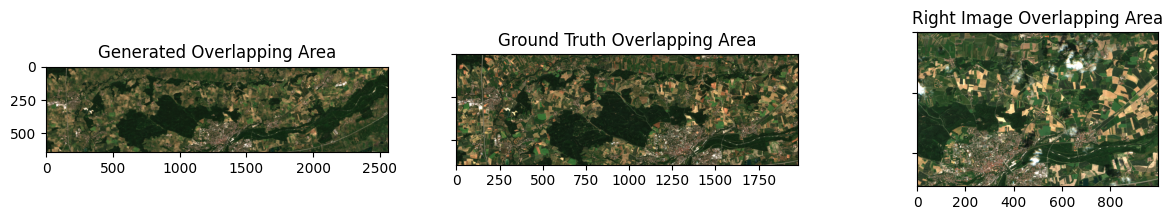

In [21]:
# print(left_img.shape, right_img.shape)
fig, ax = plt.subplots(1, 3, figsize=(15,2), sharey=True)
ax[0].imshow(s2_to_rgb(generated_patches))
ax[0].set_title("Generated Overlapping Area")
ax[1].imshow(left_img[3000:3640,9000:])
ax[1].set_title("Ground Truth Overlapping Area")
ax[2].imshow(right_img[3000:3640,0:1000])
ax[2].set_title("Right Image Overlapping Area")
plt.show()


In [8]:
model.eval()

dt = datetime(2023, 6, 25, 10, 16, 1)
t0 = datetime(2015, 1, 1)
delta = (dt - t0).total_seconds() / 86400.0  # days since t0


import itertools
patch_size = 128
x_start, x_end = 15000, 17560
y_start, y_end = 3000, 3640

x_coords = range(x_start, x_end - patch_size + 1, patch_size)
y_coords = range(y_start, y_end - patch_size + 1, patch_size)

xy_pairs = list(itertools.product(x_coords, y_coords))
xy_tensor = torch.tensor(xy_pairs, dtype=torch.long)
generated_patches = np.empty(shape=(12, 640, 2560))
for coord in xy_tensor:
    x0 = torch.tensor([coord[0]], dtype=torch.long)        # [1]
    y0 = torch.tensor([coord[1]], dtype=torch.long)        # [1]
    # print(x0, y0)
    generated_patches[:, coord[1]-y_start:coord[1]-y_start+patch_size, coord[0]-x_start:coord[0]-x_start+patch_size] = model(torch.Tensor([delta]), x0, y0).detach().numpy()
    # generated_patches = model(torch.Tensor([delta]), y0, x0).detach().numpy()

In [ ]:
plt.imshow(right_img[3000:3640,15000:17560])

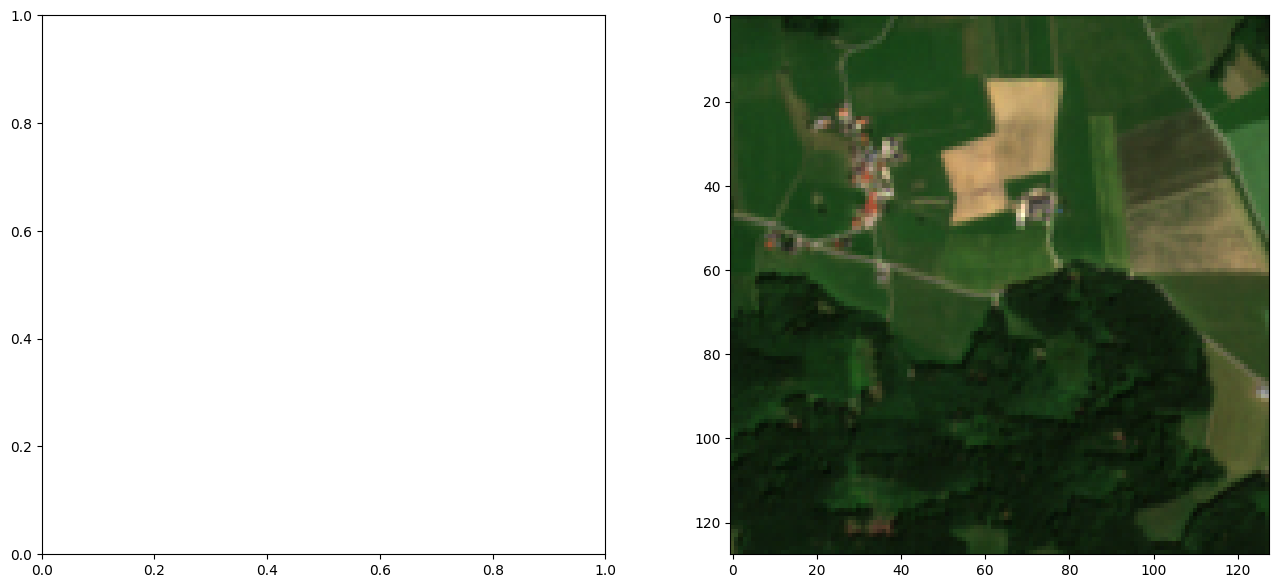

In [8]:
# print(left_img.shape, right_img.shape)
fig, ax = plt.subplots(1, 2, figsize=(16,7))
# ax[0].imshow(s2_to_rgb(generated_patches))
# ax[0].set_title("Generated Overlapping Area")
ax[1].imshow(right_img[7340:7340+128,-128:])
# ax[1].set_title("Ground Truth Overlapping Area")
# plt.show()


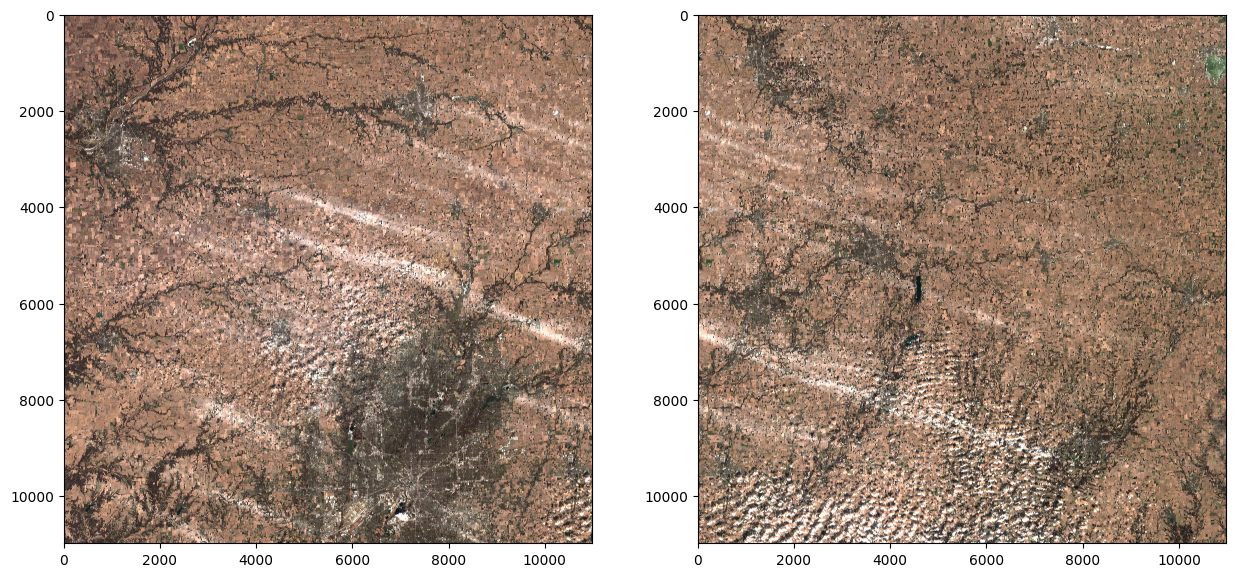

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15,7))
ax[0].imshow(left_img)
ax[1].imshow(right_img)
plt.show()

In [ ]:
import os
import glob
from abc import abstractmethod
import numpy as np
import rasterio as rio
import torch
from torch.utils.data import Dataset
from datetime import datetime
from utils import _preprocess_S2
import math

class LIANetPretrainingDataset(Dataset):
    def __init__(self, iterations_per_epoch, topdir_dataset, image_size, 
                 complete_tile_size, tile_names):
        self.topdir_dataset = topdir_dataset
        assert os.path.isdir(topdir_dataset)
        self.iterations_per_epoch = iterations_per_epoch
        self.image_size = image_size
        self.complete_tile_size = complete_tile_size
        self.tile_names_list = tile_names
        self.tiles = {}
        for tile_name in self.tile_names_list:
            tile_dir = os.path.join(self.topdir_dataset, tile_name)
            tif_files = os.listdir(tile_dir)
            self.tiles[tile_name] = tif_files


        self.overlap_x = 984 # overlap on the x direction between two adjacent tiles in the mosaic
        self.single_tile_width = 10980
        self.mosaic_width = self.single_tile_width + (self.single_tile_width - self.overlap_x)  # 10980 + 9996 = 20976

    @property
    def _epoch(self) -> int:
        return self._epoch_shared.value

    @abstractmethod
    def _rand_xy(self):
        x0 = np.random.choice(np.arange(0, self.complete_tile_size , dtype=int))
        y0 = np.random.choice(np.arange(0, self.complete_tile_size , dtype=int))
        return x0,y0
    
    @abstractmethod
    def _get_dt_properties(self, time_idx, valid_tiles):

        s2_file_name = valid_tiles[time_idx] # for now I am using everything in the train

        capture_time = os.path.splitext(os.path.basename(s2_file_name))[0]
        dt = datetime.strptime(capture_time, "%Y%m%dT%H%M%S")

        t0 = datetime(2015, 1, 1)
        delta = (dt - t0).total_seconds() / 86400.0  # days since t0

        # day-of-year
        doy = dt.timetuple().tm_yday  # 1..365/366
        doy_norm = (doy - 1) / 365.0
        doy_sin = math.sin(2 * math.pi * doy_norm)
        doy_cos = math.cos(2 * math.pi * doy_norm)

        return {"file_name": s2_file_name,"delta_days": delta, "doy_sin": doy_sin, "doy_cos": doy_cos,}

    @abstractmethod
    def __getitem__(self, i):

        # select a random tile index
        tile_idx = np.random.randint(0, len(self.tile_names_list)) #TODO: add weights based on number of files per tile
        tile_name = self.tile_names_list[tile_idx]
        # excluding 2024 from training set and selecting a random time index from the rest 
        # valid_tiles = [f for f in self.tiles[tile_name] 
        #     if f.endswith(".tif") and not f.startswith("2024")
        # ]
        valid_tiles = [f for f in self.tiles[tile_name] 
            if f.endswith(".tif")
        ]
        time_idx = np.random.randint(0, len(valid_tiles))
        dt_properties = self._get_dt_properties(time_idx, valid_tiles)

        # select a random spatial location
        x0, y0 = self._rand_xy()
        # Use it in image space
        x0_img = self.single_tile_width - self.image_size if x0 > self.single_tile_width - self.image_size else x0
        y0_img = self.single_tile_width - self.image_size if y0 > self.single_tile_width - self.image_size else y0
        window = rio.windows.Window(col_off=x0_img, row_off=y0_img,
                                    width=self.image_size, height=self.image_size)
        s2_path = glob.glob(os.path.join(self.topdir_dataset, tile_name ,f"{dt_properties['file_name']}"))
        assert len(s2_path) == 1
        s2_path = s2_path[0]
        with rio.open(s2_path) as src:
            patch = src.read(window=window)
        patch = _preprocess_S2(patch)

        x_offset = tile_idx * (self.single_tile_width - self.overlap_x)  # 0 for first tile, 9996 for second
        x0_latent = x_offset + x0_img
        y0_latent = y0_img

        # clamp so the whole patch stays inside mosaic
        x0_latent = min(x0_latent, self.mosaic_width - self.image_size)
        y0_latent = min(y0_latent, self.single_tile_width - self.image_size)

        return {
            "delta_days": torch.tensor(dt_properties["delta_days"], dtype=torch.float32),
            "time_idx": torch.tensor(time_idx, dtype=torch.int32),
            "doy_sin": torch.tensor(dt_properties["doy_sin"], dtype=torch.float32),
            "doy_cos": torch.tensor(dt_properties["doy_cos"], dtype=torch.float32),
            "x_s2": x0_latent,
            "y_s2": y0_latent,
            "x_s2_img": x0_img,
            "y_s2_img": y0_img,
            "tile_name": tile_name,
            "s2data": patch
        }

    def __len__(self): return self.iterations_per_epoch



if __name__ == "__main__":
    dataset = LIANetPretrainingDataset(iterations_per_epoch=1000,
                             topdir_dataset="/home/user/data/extended_area_experiment_data",
                             image_size=128,
                             complete_tile_size=10980,
                             tile_names=["T32UPU", "T32UQU"])
    i = dataset[0]
    print(i['tile_name'])

T32UPU


In [16]:
from collections import defaultdict
import numpy as np

def inspect_ranges(dataset, N=20000):
    mins = defaultdict(lambda: [10**9, 10**9])
    maxs = defaultdict(lambda: [-10**9, -10**9])

    xs_all = []
    for i in range(N):
        s = dataset[i]
        t = s["tile_name"]
        x, y = int(s["x_s2"]), int(s["y_s2"])
        mins[t][0] = min(mins[t][0], x); mins[t][1] = min(mins[t][1], y)
        maxs[t][0] = max(maxs[t][0], x); maxs[t][1] = max(maxs[t][1], y)
        xs_all.append(x)

    print("Per-tile x/y latent ranges:")
    for t in mins:
        print(f"{t}: x [{mins[t][0]}, {maxs[t][0]}], y [{mins[t][1]}, {maxs[t][1]}]")

    xs_all = np.array(xs_all)
    print("\nOverall x coverage:")
    print("min/max:", xs_all.min(), xs_all.max())

# usage:
inspect_ranges(dataset, N=50000)


Per-tile x/y latent ranges:
T32UPU: x [0, 10852], y [0, 10852]
T32UQU: x [9996, 20848], y [0, 10852]

Overall x coverage:
min/max: 0 20848


In [17]:
def check_overlap_consistency(tile_w=10980, overlap_x=984, image_size=128):
    offset1 = tile_w - overlap_x  # 9996
    # pick some local x in the overlap region for tile 0:
    # overlap starts at local x = 9996
    for local_x0 in [9996, 10000, 10500, 10800]:
        global_x = local_x0
        # what local x would tile1 need to produce the same global_x?
        local_x1 = global_x - offset1
        print(f"global_x={global_x}  tile0 local={local_x0}  tile1 local={local_x1}")

check_overlap_consistency()


global_x=9996  tile0 local=9996  tile1 local=0
global_x=10000  tile0 local=10000  tile1 local=4
global_x=10500  tile0 local=10500  tile1 local=504
global_x=10800  tile0 local=10800  tile1 local=804


In [18]:
def find_mismatches(dataset, N=20000, show=20):
    bad = 0
    for i in range(N):
        s = dataset[i]
        tile = s["tile_name"]
        x_img = int(s["x_s2_img"])
        x_lat = int(s["x_s2"])

        # Recompute what x_lat SHOULD be if it’s based on x_img.
        # You need to know tile index from tile_name:
        # Build mapping based on dataset.tile_names_list order.
        tile_idx = dataset.tile_names_list.index(tile)
        overlap_x = 984
        tile_w = 10980
        offset = tile_idx * (tile_w - overlap_x)
        x_expected = min(offset + x_img, (tile_w + (tile_w - overlap_x)) - dataset.image_size)

        if x_lat != x_expected:
            bad += 1
            if bad <= show:
                print(f"Mismatch: tile={tile}, x_img={x_img}, x_lat={x_lat}, expected={x_expected}")
    print("Total mismatches:", bad, "out of", N)

find_mismatches(dataset, N=50000)


Total mismatches: 0 out of 50000
